# 📊 Estudo de Caso: Desempenho de Alunos

Você foi contratado como cientista de dados para analisar o desempenho de uma turma.
Seu objetivo é gerar insights para melhorar o ensino.

Utilizando o material e as métricas apresentadas na aula de hoje, apresente seus _insigths_ para o _dataset_ apresentado:

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset_estudo_estatistica.csv')
df.head()

,horas_estudo,acessos_plataforma,faltas,tempo_resolucao,bolsa_estagio,turno,linguagem,nota
0,7,39,10,167,1,Manhã,Java,75.596400
1,4,39,9,183,1,Manhã,Java,0.000000
2,8,37,6,166,0,Manhã,C,66.178579
3,5,9,11,109,0,Noite,Python,35.059806
4,7,110,8,166,1,Noite,C,57.371902


## Exercício 1
Descreva e analise algo relevante nos dados.

A primeira análise será feita em relação a coluna de horas de estudo. O objetivo é identificar a existência de outliers e verificar qual é a melhor medida de tendência central que pode ser aplicada para descrever o comportamento do conjunto. Para isso será utilizada uma função que determina se há outliers e quais são, a partir do método IQR:

In [31]:
def outliers_iqr (df, column):

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return df[(df[column] < lower) | (df[column] > upper)]

outliers_horas_estudo = outliers_iqr(df, 'horas_estudo')
len(outliers_horas_estudo)

0

## Exercício 2
Descreva e analise algo relevante nos dados.

Como não há nenhum outlier que afete a análise de tendência central através da média aritmética simples, vamos aplicá-la para entender melhor o comportamente desse conjunto de dados. Além disso, vamos verificar também o desvio padrão, para identificar a estabilidade dos dados, e encontrar os valores extremos (máximo e mínimo):

In [34]:
def column_info (df, column):

    print("Dados referentes a " + column + ":")
    print(f"Média = {np.mean(df[column])}")
    print(f"Desvio Padrão = {np.std(df[column])}")
    print(f"Máximo = {np.max(df[column])}")
    print(f"Mínimo = {np.min(df[column])}\n")

column_info(df, 'horas_estudo')

Dados referentes a horas_estudo:
Média = 5.3625
Desvio Padrão = 2.5992486895254943
Máximo = 9
Mínimo = 1



A média de horas de estudo está próxima de 5. Vale destacar que, mesmo que não apresente outliers, a variabilidade do conjunto é alta. A distância da média para os extremos é de cerca de 4 horas.

## Exercício 3
Descreva e analise algo relevante nos dados.

Vamos efetuar a mesma análise realizada anteriormente para a coluna que referencia a quantidade de acessos a plataforma:

In [32]:
print(len(outliers_iqr(df, 'acessos_plataforma')))

0


In [35]:
column_info(df, 'acessos_plataforma')

Dados referentes a acessos_plataforma:
Média = 59.95
Desvio Padrão = 33.70752883259169
Máximo = 119
Mínimo = 5



## Exercício 4
Descreva e analise algo relevante nos dados.

Vamos analisar agora as frequências absoluta e relativa da coluna binária que identifica se o indivíduo possui bolsa de estágio ou não. Para isso podemos usar a ferramenta de moda, visto que só temos duas classes (possui bolsa = 1 ou não possui bolsa = 0):

In [3]:
def mode (df, column):

    mode = df[column].mode()
    count = (df[column] == mode[0]).sum()
    print(f"Moda = {mode[0]}")
    print(f"Frequência Absoluta = {count}")
    print(f"Frequência Relativa = {(count/df[column].size)*100}")

mode(df, 'bolsa_estagio')

Moda = 1
Frequência Absoluta = 41
Frequência Relativa = 51.24999999999999


Sendo assim, conclui-se que há mais indivíduos que possuem bolsa de estágio, ainda que a frequência absoluta de indivíduos com bolsa seja muito próxima da frequência de indivíduos sem bolsa.

## Exercício 5
Descreva e analise algo relevante nos dados.

Para analisar a coluna de turnos podemos fazer a mesma análise realizada no exercício anterior. Primeiro identificamos a moda e então determinamos sua frequência absoluta e relativa. Para facilitar a visualização, dessa vez apresentaremos os resultados também em um gráfico de setores:

Moda = Noite
Frequência Absoluta = 45
Frequência Relativa = 56.25


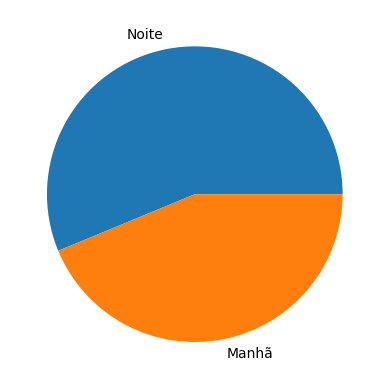

In [8]:
mode(df, 'turno')

frequency = df['turno'].value_counts()

plt.figure()
frequency.plot.pie(labels = frequency.index)
plt.show()

## Exercício 6
Descreva e analise algo relevante nos dados.

Vamos observar a possível existência de correlação entre as horas de estudo e a nota do aluno. Para isso vamos criar uma matriz de correlação que poderá ser utilizada em análises posteriores:

Correlação entre horas de estudo e nota: 0.9180856640311844


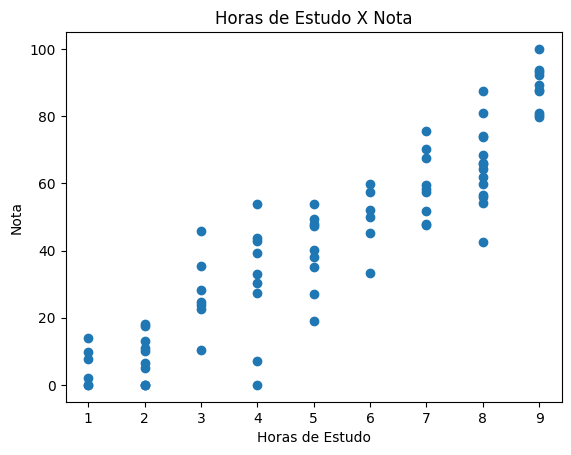

In [10]:
corr = df.corr(numeric_only = True)
print("Correlação entre horas de estudo e nota:", corr['nota']['horas_estudo'])

plt.figure()
plt.scatter(df['horas_estudo'], df['nota'])
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota')
plt.title('Horas de Estudo X Nota')
plt.show()

Observa-se que a correlação é muito alta. Ou seja, podemos inferir que quanto mais o aluno estuda, maior tende a ser a sua nota.

## Exercício 7
Descreva e analise algo relevante nos dados.

Agora vamos utilizar a matriz de correlação para verificar se há alguma relação entre a quantidade de acessos a plataforma e a nota do aluno:

Correlação entre acessos e nota: -0.14007793949003985


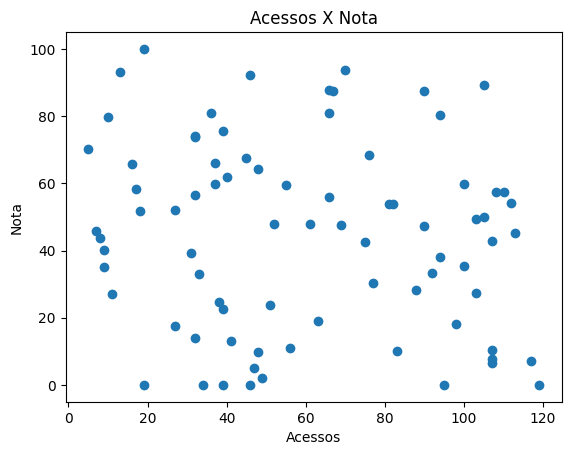

In [12]:
print("Correlação entre acessos e nota:", corr['nota']['acessos_plataforma'])

plt.figure()
plt.scatter(df['acessos_plataforma'], df['nota'])
plt.xlabel('Acessos')
plt.ylabel('Nota')
plt.title('Acessos X Nota')
plt.show()

A correlação entre essas variáveis é extremamente fraca e, ainda por cima, negativa. Sendo assim, é possível inferir que os acessos à plataforma não garantem um bom desempenho, ou seja, a qualidade do estudo é mais importante que a quantidade de acessos.

## Exercício 8
Descreva e analise algo relevante nos dados.

Agora vamos usar a matriz de correlação para verificar se há relação entre as variáveis que indicam a quantidade de faltas do aluno e a sua nota:

Correlação entre faltas e nota: -0.19672431514472122


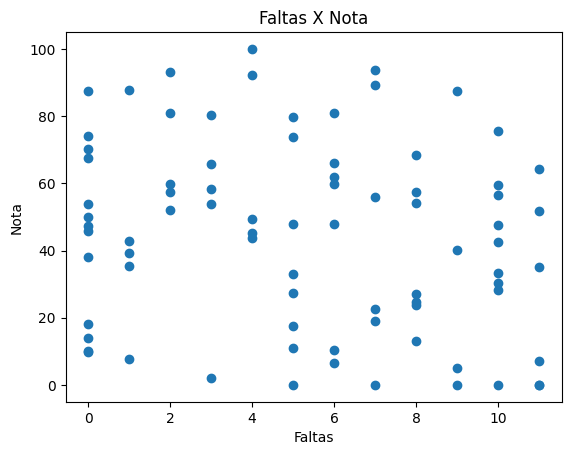

In [13]:
print("Correlação entre faltas e nota:", corr['nota']['faltas'])

plt.figure()
plt.scatter(df['faltas'], df['nota'])
plt.xlabel('Faltas')
plt.ylabel('Nota')
plt.title('Faltas X Nota')
plt.show()

As variáveis apresentam uma fraca correlação negativa. Sendo assim, é possível inferir que as faltas podem causar um leve impacto negativo na nota do aluno, ou seja, alunos que faltam mais tendem a ter notas piores, mesmo que o impacto seja pequeno.

## Exercício 9
Descreva e analise algo relevante nos dados.

Vamos agora verificar se há relação entre o tempo que o aluno levou para solucionar os problemas e a nota que obteve:

Correlação entre tempo de resolução e nota: -0.030751054744315172


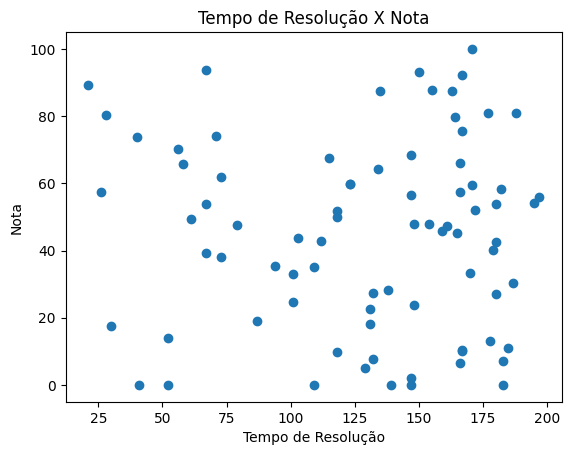

In [14]:
print("Correlação entre tempo de resolução e nota:", corr['nota']['tempo_resolucao'])

plt.figure()
plt.scatter(df['tempo_resolucao'], df['nota'])
plt.xlabel('Tempo de Resolução')
plt.ylabel('Nota')
plt.title('Tempo de Resolução X Nota')
plt.show()

Nota-se que o tempo de resolução não influencia significativamente na nota obtida pelo aluno. Ou seja, resolver rápido ou devagar não está associado ao desempenho.

## Exercício 10
Descreva e analise algo relevante nos dados.

A última análise de correlação que faremos é entre a quantidade de horas de estudo e o número de faltas. Vamos verificar se o aluno faltar mais implica em ter menos horas de estudo:

Correlação entre horas de estudo e faltas: 0.039519799162140566


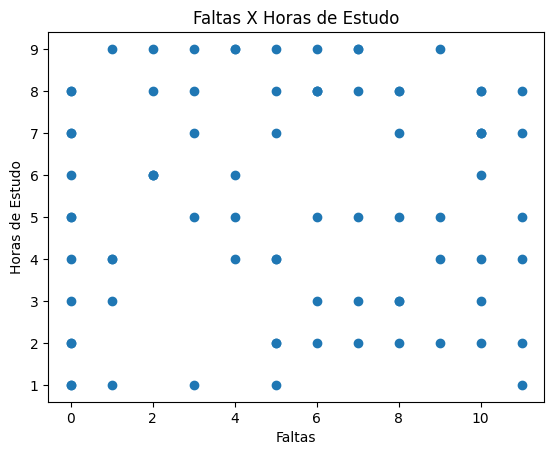

In [16]:
print("Correlação entre horas de estudo e faltas:", corr['horas_estudo']['faltas'])

plt.figure()
plt.scatter(df['faltas'], df['horas_estudo'])
plt.xlabel('Faltas')
plt.ylabel('Horas de Estudo')
plt.title('Faltas X Horas de Estudo')
plt.show()

Não existe correlação entre essas variáveis. Sendo assim, podemos inferir que menos estudo não significa que o aluno possui mais faltas. Ou seja, alunos que estudam mais não necessariamente faltam menos.

## Exercício 11
Descreva e analise algo relevante nos dados.

Vamos olhar o dataset sob um diferente ponto de vista dessa vez. Não iremos correlacionar as variáveis, mas tentar identificar uma situação específica. O objetivo é listar os alunos que apresentam um baixo desempenho, mas ainda assim tem uma grande quantidade de horas de estudo:

In [17]:
df[(df['horas_estudo'] > df['horas_estudo'].mean()) & (df['nota'] < df['nota'].mean())]

,horas_estudo,acessos_plataforma,faltas,tempo_resolucao,bolsa_estagio,turno,linguagem,nota
17,6,92,10,170,1,Manhã,Python,33.277828
62,8,75,10,180,1,Noite,Java,42.622988


Encontramos dois alunos que se encaixam nessa situação. Ambos apresentam um valor alto de horas de estudo e acessos a plataforma, mas uma nota baixa e um valor alto para tempo de resolução. É interessante apontar que ambos os alunos também apresentam um alto número de faltas registradas.

## Exercício 12
Descreva e analise algo relevante nos dados.

Para que possamos ter um melhor entendimento da distribuição das notas dos alunos, vamos agora realizar um boxplot desses valores:

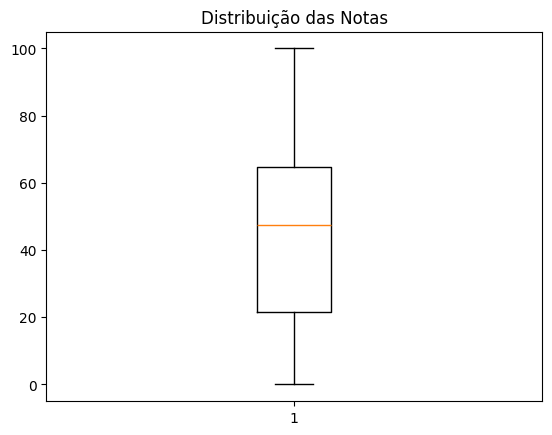

In [18]:
plt.figure()
plt.boxplot(df['nota'])
plt.title('Distribuição das Notas')
plt.show()

Como já havíamos constatado anteriormente, não há nenhum outlier. Além disso, há uma distribuição maior de notas abaixo da média do que acima.

## Exercício 13
Descreva e analise algo relevante nos dados.

Para entender em quais intervalos de valores as notas se concentram, podemos utilizar um histograma, como apresentado a seguir:

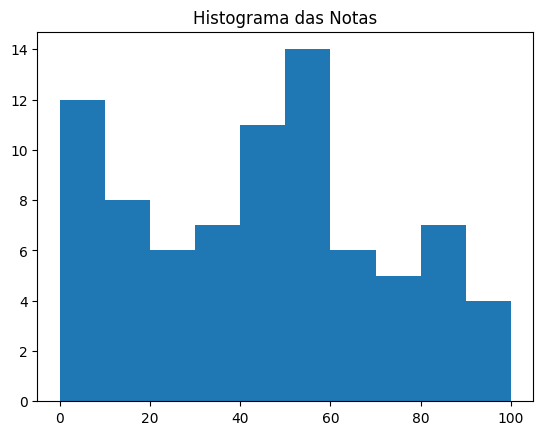

In [19]:
plt.figure()
plt.hist(df['nota'], bins=10)
plt.title('Histograma das Notas')
plt.show()

Aqui podemos observar com clareza que a maior concentração de notas está próximo da média e em valores que estão abaixo da média. Ou seja, no geral o desempenho dos alunos foi insatisfatório.

## Exercício 14
Descreva e analise algo relevante nos dados.

Para termos uma melhor visualização da correlação entre as variáveis do dataset, podemos utilizar um heatmap de correlação:

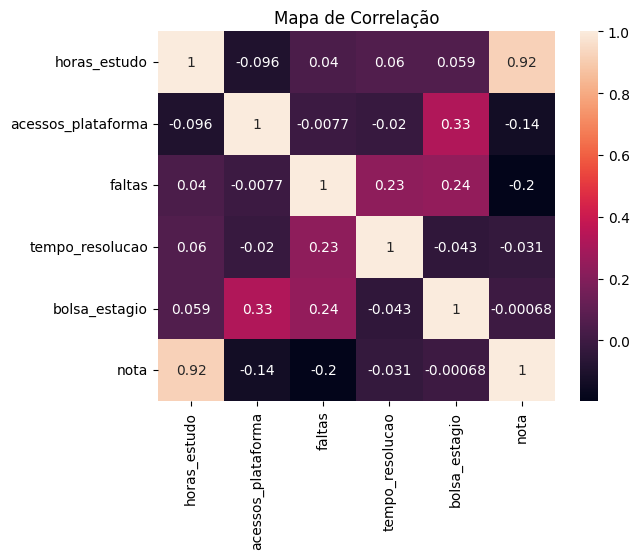

In [21]:
plt.figure()
sns.heatmap(corr, annot = True)
plt.title('Mapa de Correlação')
plt.show()

Nota-se que a única correlação significativa observada é entre as variáveis que indicam as horas de estudo e a nota dos alunos.

## Exercício 15
Descreva e analise algo relevante nos dados.

Vamos observar a quantidade de alunos dedicado a cada linguagem:

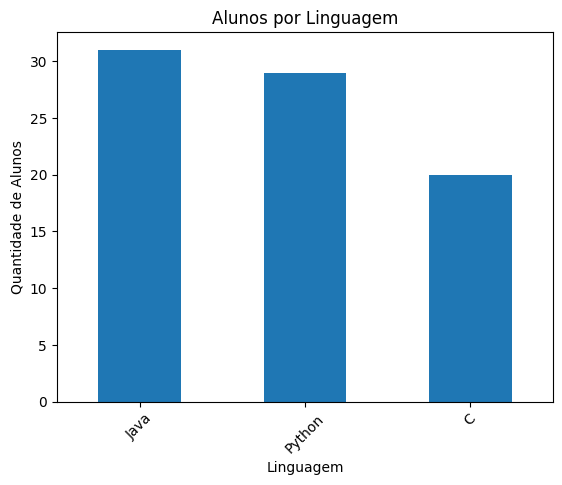

In [23]:
count_linguagem = df['linguagem'].value_counts()

plt.figure()
count_linguagem.plot(kind = 'bar')
plt.xlabel('Linguagem')
plt.ylabel('Quantidade de Alunos')
plt.title('Alunos por Linguagem')
plt.xticks(rotation = 45)
plt.show()

A maior parte dos alunos se dedica ao estudo de Java, apesar da quantidade de alunos que estudam Python ser bem próxima. A menor parte deles se dedica ao estudo de C.

## Exercício 16
Descreva e analise algo relevante nos dados.

In [25]:
noturno = df[df['turno'] == "Noite"]
acessos_noite = noturno['acessos_plataforma'].mean()
print(acessos_noite)

diurno = df[df['turno'] == "Manhã"]
acessos_dia = diurno['acessos_plataforma'].mean()
print(acessos_dia)

66.26666666666667
51.82857142857143


## Exercício 17
Descreva e analise algo relevante nos dados.

In [29]:
bolsista = df[df['bolsa_estagio'] == 1]
nota_bolsista = noturno['nota'].mean()
print(nota_bolsista)

nao_bolsista = df[df['bolsa_estagio'] == 0]
nota_nao_bolsista = nao_bolsista['nota'].mean()
print(nota_nao_bolsista)

42.560955543941695
44.65459478664968


## Exercício 18
Descreva e analise algo relevante nos dados.

In [36]:
print(len(outliers_iqr(df, 'faltas')))
column_info(df, 'faltas')

0
Dados referentes a faltas:
Média = 5.275
Desvio Padrão = 3.653679652076794
Máximo = 11
Mínimo = 0



## Exercício 19
Descreva e analise algo relevante nos dados.

In [37]:
print(len(outliers_iqr(df, 'tempo_resolucao')))
column_info(df, 'tempo_resolucao')

0
Dados referentes a tempo_resolucao:
Média = 128.4125
Desvio Padrão = 48.03194087011267
Máximo = 197
Mínimo = 21



## Exercício 20
Descreva e analise algo relevante nos dados.

In [38]:
print(len(outliers_iqr(df, 'nota')))
column_info(df, 'nota')

0
Dados referentes a nota:
Média = 44.63521894022
Desvio Padrão = 27.81004798633209
Máximo = 100.0
Mínimo = 0.0

